# Greedy Construction Heuristic for VRPTW

In [1]:
import math
import random

class Customer:
    def __init__(self, id, x, y, demand, ready_time, due_time, service_time=0):
        self.id = id
        self.x = x
        self.y = y
        self.demand = demand
        self.ready_time = ready_time
        self.due_time = due_time
        self.service_time = service_time

    def __repr__(self):
        return f"Customer({self.id}, demand={self.demand}, window=[{self.ready_time},{self.due_time}])"


def distance(c1, c2):
    return math.hypot(c1.x - c2.x, c1.y - c2.y)


class VRPTWInstance:
    def __init__(self, depot, customers, vehicle_capacity, num_vehicles):
        self.depot = depot
        self.customers = customers
        self.vehicle_capacity = vehicle_capacity
        self.num_vehicles = num_vehicles

    def all_nodes(self):
        return [self.depot] + self.customers


def generate_vrptw_instance(n_customers, vehicle_capacity=100, num_vehicles=5, seed=42):
    rng = random.Random(seed)
    depot = Customer("Depot", 50, 50, 0, 0, 1000, 0)
    customers = []
    for i in range(n_customers):
        x, y = rng.randint(0, 100), rng.randint(0, 100)
        demand = rng.randint(5, 30)
        ready = rng.randint(0, 400)
        due = ready + rng.randint(50, 200)
        service = rng.randint(5, 15)
        customers.append(Customer(f"C{i}", x, y, demand, ready, due, service))
    return VRPTWInstance(depot, customers, vehicle_capacity, num_vehicles)


def route_feasible(route, instance):
    total_demand = sum(c.demand for c in route)
    if total_demand > instance.vehicle_capacity:
        return False, None, None

    current_time = 0.0
    current_pos = instance.depot
    total_dist = 0.0
    arrival_times = []

    for customer in route:
        travel = distance(current_pos, customer)
        arrival = current_time + travel
        start_service = max(arrival, customer.ready_time)
        if start_service > customer.due_time:
            return False, None, None

        arrival_times.append(start_service)
        current_time = start_service + customer.service_time
        total_dist += travel
        current_pos = customer

    total_dist += distance(current_pos, instance.depot)
    return True, total_dist, arrival_times


def solution_total_distance(routes, instance):
    total = 0.0
    for route in routes:
        feasible, dist, _ = route_feasible(route, instance)
        if not feasible:
            return None
        total += dist
    return total

## Greedy Nearest-Feasible-Neighbour Construction

In [2]:
def greedy_construction(instance):
    """
    Builds routes one vehicle at a time. For the current vehicle, repeatedly
    picks the nearest unvisited customer that is still feasible to insert
    (capacity + time window), until no feasible customer remains, then
    starts a new vehicle. Stops when all customers are routed or vehicles
    run out.
    """
    unvisited = list(instance.customers)
    routes = []

    for _ in range(instance.num_vehicles):
        if not unvisited:
            break

        route = []
        current_pos = instance.depot
        current_time = 0.0
        current_load = 0

        while True:
            best_customer = None
            best_dist = float('inf')

            for customer in unvisited:
                if current_load + customer.demand > instance.vehicle_capacity:
                    continue
                travel = distance(current_pos, customer)
                arrival = current_time + travel
                start_service = max(arrival, customer.ready_time)
                if start_service > customer.due_time:
                    continue

                if travel < best_dist:
                    best_dist = travel
                    best_customer = customer

            if best_customer is None:
                break  # no feasible customer left for this vehicle

            route.append(best_customer)
            travel = distance(current_pos, best_customer)
            arrival = current_time + travel
            current_time = max(arrival, best_customer.ready_time) + best_customer.service_time
            current_load += best_customer.demand
            current_pos = best_customer
            unvisited.remove(best_customer)

        if route:
            routes.append(route)

    return routes, unvisited  # unvisited = customers that couldn't be served

## Sanity Test

In [3]:
import time

instance = generate_vrptw_instance(n_customers=20)

t0 = time.perf_counter()
routes, unserved = greedy_construction(instance)
elapsed = time.perf_counter() - t0

total_dist = solution_total_distance(routes, instance)

print(f"Number of routes (vehicles used): {len(routes)}")
for i, route in enumerate(routes):
    feasible, dist, _ = route_feasible(route, instance)
    print(f"  Vehicle {i+1}: {[c.id for c in route]}  (distance={dist:.2f}, feasible={feasible})")

print(f"\nTotal distance: {total_dist:.2f}")
print(f"Unserved customers: {[c.id for c in unserved]}")
print(f"Time taken: {elapsed*1000:.2f} ms")

Number of routes (vehicles used): 5
  Vehicle 1: ['C15', 'C16', 'C13', 'C14', 'C0']  (distance=113.47, feasible=True)
  Vehicle 2: ['C6', 'C1', 'C8', 'C9', 'C11']  (distance=156.46, feasible=True)
  Vehicle 3: ['C3', 'C7', 'C12', 'C4']  (distance=210.31, feasible=True)
  Vehicle 4: ['C2', 'C19', 'C18']  (distance=114.39, feasible=True)
  Vehicle 5: ['C5', 'C10', 'C17']  (distance=163.14, feasible=True)

Total distance: 757.77
Unserved customers: []
Time taken: 0.18 ms


## Visualizing the Greedy Solution

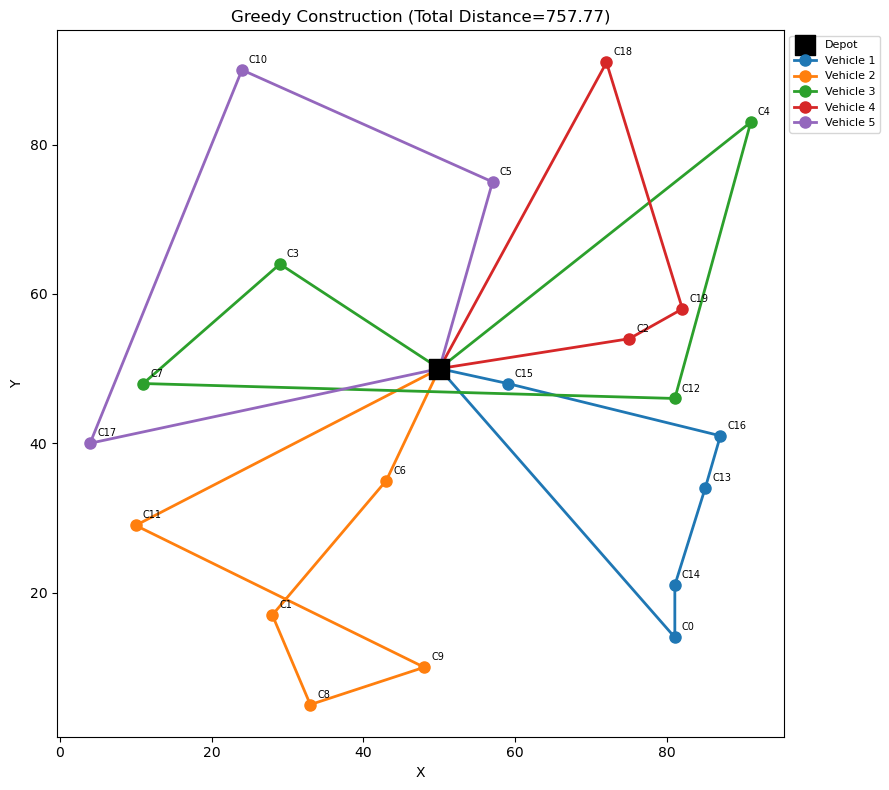

In [4]:
import matplotlib.pyplot as plt

def visualize_routes(routes, instance, title="VRPTW Solution"):
    fig, ax = plt.subplots(figsize=(9, 8))
    colors = plt.cm.tab10.colors

    ax.scatter(instance.depot.x, instance.depot.y, c='black', s=200, marker='s', zorder=5, label='Depot')

    for i, route in enumerate(routes):
        color = colors[i % len(colors)]
        xs = [instance.depot.x] + [c.x for c in route] + [instance.depot.x]
        ys = [instance.depot.y] + [c.y for c in route] + [instance.depot.y]
        ax.plot(xs, ys, marker='o', color=color, linewidth=2, markersize=8, label=f'Vehicle {i+1}')
        for c in route:
            ax.annotate(c.id, (c.x, c.y), textcoords="offset points", xytext=(5, 5), fontsize=7)

    ax.set_title(title)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.tight_layout()
    plt.show()

visualize_routes(routes, instance, title=f"Greedy Construction (Total Distance={total_dist:.2f})")